# RSNA Knee — pipeline 2.5D + DenseNet121

Clasificación **multi-label** de 12 hallazgos en RMN de rodilla, usando **todas** las series y los **tres planos**.

Aquí se arma el modelo sobre los DICOM.

Guía: [`RSNA_Knee_guia_Cursor.md`](RSNA_Knee_guia_Cursor.md) · datos: [`docs/datos.md`](docs/datos.md)

**Aún no entrenamos.** Primero tiene que funcionar `procesar_plano()` sobre un estudio (1024 por plano).


## 1. Imports y configuración

**Para qué:** dejar librerías y constantes en un solo sitio.  
**Por qué:** el resto del notebook reutiliza `device`, `LABELS` y las rutas. Kernel: **`.venv (knee)`**.


In [22]:
import os
from pathlib import Path
from dotenv import load_dotenv

for _dir in (Path.cwd(), Path.cwd() / "produccion"):
    _env = _dir / ".env"
    if _env.exists():
        load_dotenv(_env)
        break
else:
    load_dotenv()

print("BASE_PATH del .env:")
print(os.environ.get("BASE_PATH"))

print("\nDiscos montados:")
volumes = Path("/Volumes")
for x in volumes.iterdir():
    print(" -", x)

BASE = Path(os.environ["BASE_PATH"])

print("\nBASE:")
print(BASE)
print("Existe BASE:", BASE.exists())

print("\nContenido de BASE:")
if BASE.exists():
    for x in BASE.iterdir():
        print(" -", x.name)

BASE_PATH del .env:
/Volumes/ADATA HD680/KAGGLE_RSNA

Discos montados:
 - /Volumes/Macintosh HD
 - /Volumes/ADATA HD680
 - /Volumes/CleanMyMac

BASE:
/Volumes/ADATA HD680/KAGGLE_RSNA
Existe BASE: True

Contenido de BASE:
 - dataset_extraido
 - train_cursor.csv
 - train_original.csv
 - train_series.csv


In [23]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pydicom
import torch
import torch.nn as nn
import torch.nn.functional as F
from dotenv import load_dotenv
from IPython.display import display
from torchvision.models import DenseNet121_Weights, densenet121

for _dir in (Path.cwd(), Path.cwd() / "produccion"):
    _env = _dir / ".env"
    if _env.exists():
        load_dotenv(_env)
        break
else:
    load_dotenv()

BASE = Path(os.environ["BASE_PATH"])
TRAIN = BASE / os.environ.get("TRAIN_CSV", "train_cursor.csv")
DATASET = BASE / "dataset_extraido"
TRAIN_IMAGES = DATASET / "train_series"

IMAGE_SIZE = 224
FEATURE_DIM = 1024
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Dispositivo:", device)
print("Imágenes:", TRAIN_IMAGES, "→", TRAIN_IMAGES.exists())
assert TRAIN_IMAGES.exists(), "Monta el disco ADATA HD680" 


Dispositivo: mps
Imágenes: /Volumes/ADATA HD680/KAGGLE_RSNA/dataset_extraido/train_series → True


## 2. Rutas y carga de tablas

**Para qué:** tener `train_df` (una fila = una rodilla) y `series_df` (una fila = una secuencia).  
**Por qué:** las imágenes no están en el CSV; se unen por `StudyInstanceUID` y `SeriesInstanceUID` con carpetas en el disco.


Para llenar la tabla, en vez llamr una api con el agente de cursror y claude llenamos la base de datos 


In [24]:
train_df = pd.read_csv(TRAIN)
series_df = pd.read_csv(BASE / "train_series.csv")

train_df["StudyInstanceUID"] = train_df["StudyInstanceUID"].astype(str)
series_df["StudyInstanceUID"] = series_df["StudyInstanceUID"].astype(str)
series_df["SeriesInstanceUID"] = series_df["SeriesInstanceUID"].astype(str)

LABELS = [
    c for c in train_df.columns
    if c not in ["StudyInstanceUID", "Report"]
]

print("BASE:", BASE)
print("train_df:", train_df.shape)
print("series_df:", series_df.shape)
print("Etiquetas:", LABELS)
assert len(LABELS) == 12
display(train_df.head(2))
display(series_df.head(2))


BASE: /Volumes/ADATA HD680/KAGGLE_RSNA
train_df: (4407, 14)
series_df: (24371, 5)
Etiquetas: ['ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus', 'Medial OA', 'Lateral OA', 'PF OA', 'Effusion', 'Synovitis', "Baker's", 'Contusion', 'Fracture']


,StudyInstanceUID,Report,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,Técnica: RMN de la rodilla. Resultados: Rotura...,0,0,1,0,1,0,0,1,0,0,0,0
1,1.2.826.0.1.3680043.8.498.10004945927472656027...,[DATE]: * MR Knie Rechts 15ch AA Klinische Inl...,0,0,0,0,0,0,0,0,0,0,0,0


,StudyInstanceUID,SeriesInstanceUID,Fluid_Sensitive,Fat_Suppression,Anatomical_Plane
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.12343110195036213483...,1,1,Sagittal
1,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.13821229744997220641...,1,1,Axial


## 3. Validación de datos

Comprobar **antes** de armar el modelo que las tablas, los planos y un DICOM real coinciden. Esto no se vuelve a hacer en cada época de entrenamiento.


### 3.1 Shapes y columnas

**Para qué:** confirmar 4407 estudios y ~24371 series, con las 12 etiquetas.  
**Por qué:** si falta una columna o hay NaN, el modelo multi-label no se puede entrenar.


In [25]:
print("COLUMNAS train_df:", train_df.columns.tolist())
print("COLUMNAS series_df:", series_df.columns.tolist())
print("NaN en etiquetas:", int(train_df[LABELS].isna().sum().sum()))
print("Estudios únicos train:", train_df["StudyInstanceUID"].nunique())
print("Estudios únicos series:", series_df["StudyInstanceUID"].nunique())


COLUMNAS train_df: ['StudyInstanceUID', 'Report', 'ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus', 'Medial OA', 'Lateral OA', 'PF OA', 'Effusion', 'Synovitis', "Baker's", 'Contusion', 'Fracture']
COLUMNAS series_df: ['StudyInstanceUID', 'SeriesInstanceUID', 'Fluid_Sensitive', 'Fat_Suppression', 'Anatomical_Plane']
NaN en etiquetas: 0
Estudios únicos train: 4407
Estudios únicos series: 4407


### 3.2 Planos anatómicos

**Para qué:** ver Sagittal / Coronal / Axial y cuántos planos tiene cada estudio.  
**Por qué:** la arquitectura concatena **tres** vectores (uno por plano). Si un estudio no tiene los tres, hay que saberlo.


In [26]:
print("Series por plano:")
display(series_df["Anatomical_Plane"].value_counts(dropna=False))

planos_por_estudio = (
    series_df.groupby("StudyInstanceUID")["Anatomical_Plane"].nunique()
)
print("Cuántos planos distintos tiene cada estudio:")
display(planos_por_estudio.value_counts().sort_index())

tabla_planos = pd.crosstab(
    series_df["StudyInstanceUID"],
    series_df["Anatomical_Plane"],
)
display(tabla_planos.head(10))


Series por plano:


Anatomical_Plane
Sagittal    9864
Coronal     8609
Axial       5898
Name: count, dtype: int64

Cuántos planos distintos tiene cada estudio:


Anatomical_Plane
3    4407
Name: count, dtype: int64

Anatomical_Plane,Axial,Coronal,Sagittal
StudyInstanceUID,,,
1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260,1,2,2
1.2.826.0.1.3680043.8.498.10004945927472656027199792075652399585,1,2,2
1.2.826.0.1.3680043.8.498.10009278692606631573540062909909132231,1,2,2
1.2.826.0.1.3680043.8.498.10009639203170750274174707434356622764,3,4,3
1.2.826.0.1.3680043.8.498.10013663742400736029415768216599146542,2,1,2
1.2.826.0.1.3680043.8.498.10018552945042470316597008531304016339,2,2,2
1.2.826.0.1.3680043.8.498.10018749256316287542884435387067561101,1,1,3
1.2.826.0.1.3680043.8.498.10021179701366615563817491713738306606,1,3,2
1.2.826.0.1.3680043.8.498.10021288557171866794624317186288618513,1,2,3


### 3.3 Un DICOM y coincidencia de UIDs

**Para qué:** probar la ruta `TRAIN_IMAGES / StudyUID / SeriesUID / *.dcm` y que el archivo sea el de esa fila.  
**Por qué:** si el UID del CSV no coincide con el del DICOM, el pipeline está ligando mal estudio ↔ imagen.


Estudio: 1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260
Serie: 1.2.826.0.1.3680043.8.498.12343110195036213483454091715412333772
Plano: Sagittal
Carpeta existe: True
Cortes: 22
UID estudio DICOM: 1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260
UID serie DICOM:   1.2.826.0.1.3680043.8.498.12343110195036213483454091715412333772
Tamaño: 512 x 512


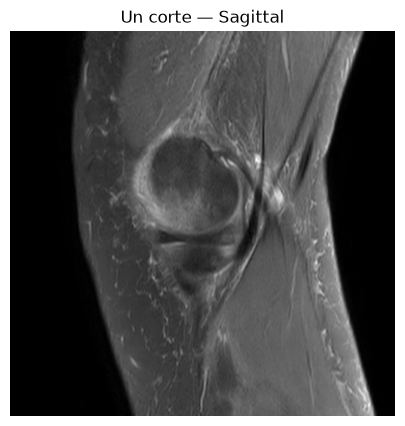

In [27]:
fila = series_df.iloc[0]
study_uid = str(fila["StudyInstanceUID"])
series_uid = str(fila["SeriesInstanceUID"])
serie_dir = TRAIN_IMAGES / study_uid / series_uid
dicoms = sorted(serie_dir.glob("*.dcm"))

print("Estudio:", study_uid)
print("Serie:", series_uid)
print("Plano:", fila["Anatomical_Plane"])
print("Carpeta existe:", serie_dir.exists())
print("Cortes:", len(dicoms))

ds = pydicom.dcmread(dicoms[0])
print("UID estudio DICOM:", ds.StudyInstanceUID)
print("UID serie DICOM:  ", ds.SeriesInstanceUID)
print("Tamaño:", ds.Rows, "x", ds.Columns)
assert str(ds.StudyInstanceUID) == study_uid
assert str(ds.SeriesInstanceUID) == series_uid

img = ds.pixel_array.astype(float)
plt.figure(figsize=(5, 5))
plt.imshow(img, cmap="gray")
plt.title(f"Un corte — {fila['Anatomical_Plane']}")
plt.axis("off")
plt.show()


### 3.4 Series de un estudio (todas las variantes)

**Para qué:** ver que un estudio trae varias secuencias por plano, con `Fluid_Sensitive` y `Fat_Suppression` 0 o 1.  
**Por qué:** **no** vamos a quedarnos solo con 1/1. Esas variantes resaltan cosas distintas; el modelo debe verlas todas y ponderarlas con Attention.


In [28]:
study_id = str(train_df.iloc[0]["StudyInstanceUID"])
series_estudio = series_df[
    series_df["StudyInstanceUID"] == study_id
][[
    "SeriesInstanceUID",
    "Anatomical_Plane",
    "Fluid_Sensitive",
    "Fat_Suppression",
]]
print("Estudio de ejemplo:", study_id)
display(series_estudio)

print("Cuántas series hay de cada tipo (en todo el dataset):")
display(
    series_df.groupby(
        ["Anatomical_Plane", "Fluid_Sensitive", "Fat_Suppression"]
    ).size().reset_index(name="Numero_series")
)

n_11 = (
    (series_df["Fluid_Sensitive"] == 1)
    & (series_df["Fat_Suppression"] == 1)
).sum()
print("Series 1/1 (info, NO se filtra el entrenamiento):", int(n_11))
print("Series totales que SÍ usamos:", len(series_df))


Estudio de ejemplo: 1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260


,SeriesInstanceUID,Anatomical_Plane,Fluid_Sensitive,Fat_Suppression
0,1.2.826.0.1.3680043.8.498.12343110195036213483...,Sagittal,1,1
1,1.2.826.0.1.3680043.8.498.13821229744997220641...,Axial,1,1
2,1.2.826.0.1.3680043.8.498.23084836536722595275...,Coronal,0,0
3,1.2.826.0.1.3680043.8.498.40734206102458723096...,Coronal,1,1
4,1.2.826.0.1.3680043.8.498.75714899997203615784...,Sagittal,0,0


Cuántas series hay de cada tipo (en todo el dataset):


,Anatomical_Plane,Fluid_Sensitive,Fat_Suppression,Numero_series
0,Axial,0,0,1179
1,Axial,1,1,4719
2,Coronal,0,0,3985
3,Coronal,1,1,4624
4,Sagittal,0,0,5197
5,Sagittal,1,1,4667


Series 1/1 (info, NO se filtra el entrenamiento): 14010
Series totales que SÍ usamos: 24371


## 4. Funciones DICOM

**Para qué:** cargar una serie o un estudio entero **bajo demanda** (rutas + orden), sin meter los 4407 volúmenes en RAM.  
**Por qué:** el 2.5D solo es válido si los tres cortes son vecinos **anatómicos**, no por nombre de archivo.


### 4.1 Posición del corte

Orden: normal del plano (`ImageOrientation` × `ImagePosition`) → `SliceLocation` → `InstanceNumber` → 0.


In [29]:
def posicion_corte(ds) -> float:
    try:
        orientacion = np.asarray(ds.ImageOrientationPatient, dtype=np.float32)
        posicion = np.asarray(ds.ImagePositionPatient, dtype=np.float32)
        normal = np.cross(orientacion[:3], orientacion[3:])
        return float(np.dot(posicion, normal))
    except Exception:
        if hasattr(ds, "SliceLocation"):
            try:
                return float(ds.SliceLocation)
            except Exception:
                pass
        return float(getattr(ds, "InstanceNumber", 0))


### 4.2 Leer píxeles

Algunos DICOM declaran 16 bits y traen 8 (el DataLoader se caía por eso). Esta lectura aguanta ese caso.


In [30]:
def _a_2d(img: np.ndarray) -> np.ndarray:
    img = np.squeeze(np.asarray(img))
    if img.ndim == 2:
        return img
    if img.ndim == 3:
        if img.shape[-1] <= 4:
            return img[..., 0]
        return img[img.shape[0] // 2]
    raise ValueError(f"Forma MRI inesperada: {img.shape}")


def _pixel_array_robusto(ds) -> np.ndarray:
    try:
        return np.asarray(ds.pixel_array)
    except Exception:
        pass
    rows, cols = int(ds.Rows), int(ds.Columns)
    samples = int(getattr(ds, "SamplesPerPixel", 1) or 1)
    raw = bytes(ds.PixelData)
    n_pix = rows * cols * samples
    arr = np.frombuffer(raw, dtype=np.uint8, count=min(len(raw), n_pix))
    if arr.size < n_pix:
        arr = np.pad(arr, (0, n_pix - arr.size))
    arr = arr[:n_pix]
    if samples == 1:
        return arr.reshape(rows, cols)
    return arr.reshape(rows, cols, samples)[..., 0]


def leer_corte(path) -> np.ndarray:
    ds = pydicom.dcmread(path)
    img = _a_2d(_pixel_array_robusto(ds)).astype(np.float32)
    if getattr(ds, "PhotometricInterpretation", "") == "MONOCHROME1":
        img = img.max() - img
    return img


### 4.3 `cargar_serie()` y `cargar_estudio()`

`cargar_serie` lista y **ordena** los DICOM de una secuencia.  
`cargar_estudio` agrupa **todas** las series en Sagittal / Coronal / Axial (sin tirar 0/0).


In [31]:
def cargar_serie(row) -> dict:
    study_uid = str(row["StudyInstanceUID"])
    series_uid = str(row["SeriesInstanceUID"])
    serie_dir = TRAIN_IMAGES / study_uid / series_uid
    cortes = []
    if serie_dir.exists():
        for archivo in serie_dir.glob("*.dcm"):
            try:
                ds = pydicom.dcmread(archivo, stop_before_pixels=True)
                cortes.append({"path": archivo, "position": posicion_corte(ds)})
            except Exception as e:
                print("Error header:", archivo.name, e)
    cortes = sorted(cortes, key=lambda x: x["position"])
    return {
        "StudyInstanceUID": study_uid,
        "SeriesInstanceUID": series_uid,
        "Anatomical_Plane": row["Anatomical_Plane"],
        "Fluid_Sensitive": int(row["Fluid_Sensitive"]),
        "Fat_Suppression": int(row["Fat_Suppression"]),
        "dicoms": cortes,
    }


def cargar_estudio(study_uid: str) -> dict:
    study_uid = str(study_uid)
    filas = series_df[series_df["StudyInstanceUID"] == study_uid]
    estudio = {"Sagittal": [], "Coronal": [], "Axial": []}
    for _, row in filas.iterrows():
        plano = row["Anatomical_Plane"]
        if plano not in estudio:
            continue
        estudio[plano].append(cargar_serie(row))
    return estudio


estudio = cargar_estudio(study_id)
for plano, series in estudio.items():
    print(plano, "→", len(series), "series,",
          [len(s["dicoms"]) for s in series], "cortes")


Sagittal → 2 series, [22, 22] cortes
Coronal → 2 series, [16, 16] cortes
Axial → 1 series, [18] cortes


## 5. Preprocesamiento

**Para qué:** pasar de archivos DICOM a tensores que DenseNet entiende.  
**Por qué:** intensidades MRI cambian entre equipos; tres cortes vecinos dan contexto 2.5D sin una CNN 3D; DenseNet espera 224×224×3 estilo ImageNet.


### 5.1 Volumen y normalización (percentiles 1–99)

Clip + escala a ~0–1. Así se recortan brillos extremos sin usar min/max crudos.


In [32]:
def serie_a_volumen(serie: dict) -> np.ndarray:
    imagenes = [leer_corte(c["path"]) for c in serie["dicoms"]]
    if not imagenes:
        return np.zeros((0, 1, 1), dtype=np.float32)
    h, w = imagenes[0].shape[-2], imagenes[0].shape[-1]
    alineadas = []
    for img in imagenes:
        if img.shape != (h, w):
            t = torch.tensor(img).unsqueeze(0).unsqueeze(0)
            t = F.interpolate(t, size=(h, w), mode="bilinear", align_corners=False)
            img = t.squeeze().numpy()
        alineadas.append(img)
    return np.stack(alineadas, axis=0).astype(np.float32)


def normalizar_volumen(volumen: np.ndarray) -> np.ndarray:
    if volumen.size == 0:
        return volumen
    p1, p99 = np.percentile(volumen, 1), np.percentile(volumen, 99)
    volumen = np.clip(volumen, p1, p99)
    return (volumen - p1) / (p99 - p1 + 1e-8)


### 5.2 Bloques 2.5D y resize

Un bloque = corte anterior + central + siguiente (canales 0, 1, 2).  
Luego 224×224 para DenseNet121 (por ahora **ImageNet**, no RadImageNet).


In [33]:
def crear_25d(volumen: np.ndarray) -> np.ndarray:
    n = len(volumen)
    if n < 3:
        return np.zeros((0, 3, *volumen.shape[1:]), dtype=np.float32)
    bloques = [np.stack([volumen[i - 1], volumen[i], volumen[i + 1]], axis=0)
               for i in range(1, n - 1)]
    return np.stack(bloques, axis=0)


def redimensionar_bloque(bloque: np.ndarray, size: int = IMAGE_SIZE) -> torch.Tensor:
    x = torch.tensor(bloque, dtype=torch.float32).unsqueeze(0)
    x = F.interpolate(x, size=(size, size), mode="bilinear", align_corners=False)
    x = (x.squeeze(0) - IMAGENET_MEAN) / IMAGENET_STD
    return x


## 6. Visualización / QA

**Para qué:** ver que el orden recorre la rodilla y que el 2.5D son tres vecinos.  
**Por qué:** si el orden está mal, Attention y Grad-CAM no tienen sentido anatómico.


Volumen: (22, 512, 512) | bloques 2.5D: (20, 3, 512, 512)


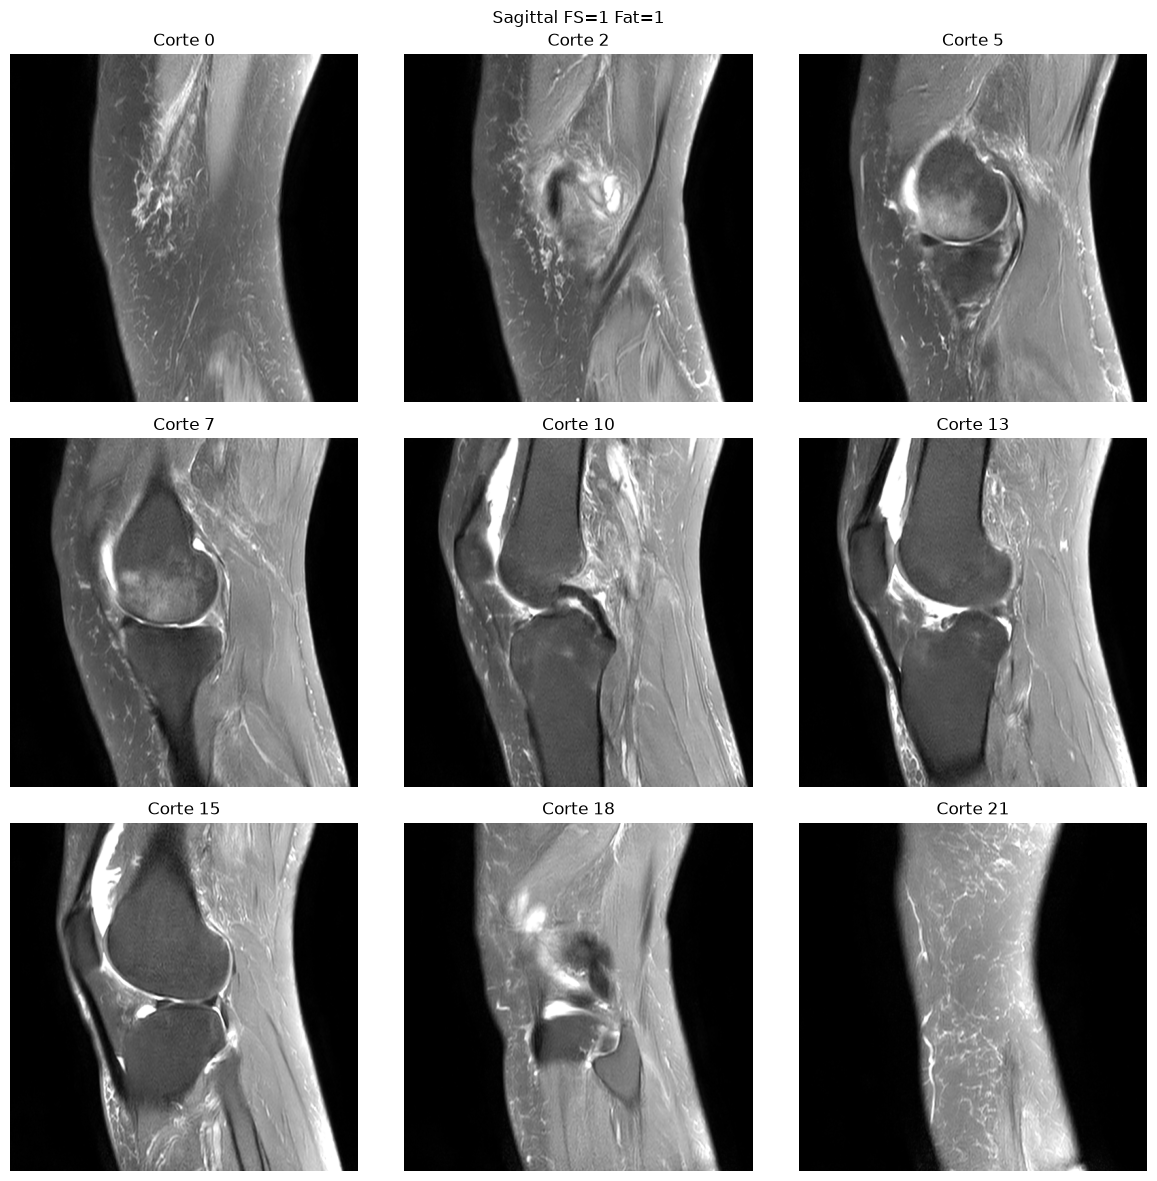

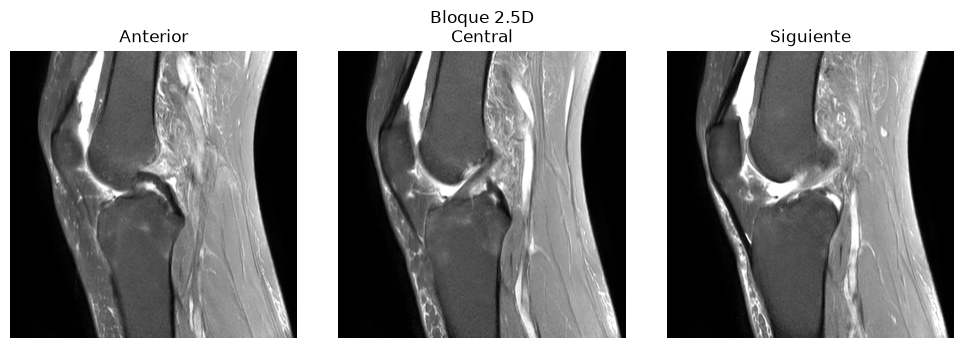

In [34]:
def mostrar_serie(volumen: np.ndarray, titulo: str = "", n: int = 9):
    if len(volumen) == 0:
        print("Serie vacía")
        return
    idxs = np.linspace(0, len(volumen) - 1, min(n, len(volumen))).astype(int)
    cols = min(3, len(idxs))
    rows = int(np.ceil(len(idxs) / cols))
    plt.figure(figsize=(4 * cols, 4 * rows))
    for i, idx in enumerate(idxs):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(volumen[idx], cmap="gray")
        plt.title(f"Corte {idx}")
        plt.axis("off")
    plt.suptitle(titulo)
    plt.tight_layout()
    plt.show()


def mostrar_25d(bloque: np.ndarray):
    fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
    for ax, canal, nombre in zip(axes, bloque, ["Anterior", "Central", "Siguiente"]):
        ax.imshow(canal, cmap="gray")
        ax.set_title(nombre)
        ax.axis("off")
    plt.suptitle("Bloque 2.5D")
    plt.tight_layout()
    plt.show()


serie_demo = estudio["Sagittal"][0]
vol = normalizar_volumen(serie_a_volumen(serie_demo))
bloques = crear_25d(vol)
print("Volumen:", vol.shape, "| bloques 2.5D:", bloques.shape)
mostrar_serie(vol, titulo=f"Sagittal FS={serie_demo['Fluid_Sensitive']} Fat={serie_demo['Fat_Suppression']}")
if len(bloques):
    mostrar_25d(bloques[len(bloques) // 2])


## 7. Backbone — DenseNet121 (ImageNet)

**Para qué:** cada bloque 2.5D (224×224×3) sale como un vector de **1024** features.  
**Por qué:** transfer learning 2D; más liviano que una CNN 3D. Pesos **ImageNet** para validar el pipeline. RadImageNet es una mejora **después**, aún no está.


In [35]:
weights = DenseNet121_Weights.IMAGENET1K_V1
densenet = densenet121(weights=weights)
extractor = densenet.features.to(device)
extractor.eval()
for param in extractor.parameters():
    param.requires_grad = False


def extraer_features(batch: torch.Tensor) -> torch.Tensor:
    feat = extractor(batch)
    return F.adaptive_avg_pool2d(feat, 1).flatten(1)


x_prueba = redimensionar_bloque(bloques[len(bloques) // 2]).unsqueeze(0).to(device)
with torch.no_grad():
    f_prueba = extraer_features(x_prueba)
print("Entrada:", tuple(x_prueba.shape), "→ features:", tuple(f_prueba.shape))
assert f_prueba.shape[-1] == FEATURE_DIM


Entrada: (1, 3, 224, 224) → features: (1, 1024)


## 8. Attention y clasificador

**Nivel 1 — cortes:** de N bloques 2.5D (N×1024) a 1×1024.  
**Nivel 2 — series:** si hay dos sagitales (0/0 y 1/1), Attention pondera las dos.  
**Clasificador:** 3072 → 512 → Dropout 0.4 → 12 logits (multi-label).

Una sola celda crea `attention_cortes`, `attention_series` y `clasificador`. Si reinicias el kernel, **vuelve a ejecutarla** (y la del `extractor`) antes del optimizer.


In [37]:
# ==========================================
# ATTENTION 1: ENTRE CORTES / BLOQUES 2.5D
# ==========================================

class AttentionCortes(nn.Module):

    def __init__(self, feature_dim=1024, hidden_dim=256):
        super().__init__()

        self.attention = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        scores = self.attention(x).squeeze(-1)
        pesos = torch.softmax(scores, dim=0)
        feature_serie = torch.sum(x * pesos.unsqueeze(-1), dim=0)
        return feature_serie, pesos


# ==========================================
# ATTENTION 2: ENTRE SERIES DEL MISMO PLANO
# ==========================================

class AttentionSeries(nn.Module):

    def __init__(self, feature_dim=1024, hidden_dim=256):
        super().__init__()

        self.attention = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        scores = self.attention(x).squeeze(-1)
        pesos = torch.softmax(scores, dim=0)
        feature_plano = torch.sum(x * pesos.unsqueeze(-1), dim=0)
        return feature_plano, pesos


# ==========================================
# CLASIFICADOR FINAL  (3072 → 12)
# ==========================================

class ClasificadorRodilla(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc = nn.Sequential(
            nn.Linear(3072, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 12)
        )

    def forward(self, x):
        return self.fc(x)


# ==========================================
# CREAR LOS OBJETOS  (antes del optimizer)
# ==========================================

attention_cortes = AttentionCortes().to(device)
attention_series = AttentionSeries().to(device)
clasificador = ClasificadorRodilla().to(device)

print("Attention cortes: OK")
print("Attention series: OK")
print("Clasificador: OK")


AttentionCortes(
  (score): Linear(in_features=1024, out_features=1, bias=True)
)
AttentionSeries(
  (score): Linear(in_features=1024, out_features=1, bias=True)
)


## 9. Funciones compactas

Encapsulan el pipeline de la guía:

```text
serie  → volumen → 2.5D → DenseNet → Attention cortes → 1024
plano  → todas las series → Attention series → 1024
estudio → Sagittal + Coronal + Axial
```

Se procesa **un** estudio. No se cargan los 4407 en lista.


In [38]:
FEATURE_CACHE = {}

_HERE = Path.cwd()
if not (_HERE / "Knee.ipynb").exists() and (_HERE / "produccion" / "Knee.ipynb").exists():
    _HERE = _HERE / "produccion"
CACHE_DIR = _HERE / "feature_cache_densenet121"
CACHE_DIR.mkdir(parents=True, exist_ok=True)


def extraer_features_serie(serie, use_cache=True):
    """Dict de serie → [N_bloques, 1024] en `device`.

    crear_25d() espera el volumen NumPy, no el dict.
    DenseNet está congelada. El .pt se escribe en el Mac (CACHE_DIR),
    nunca en el ADATA (NTFS de solo lectura).
    """
    key = str(serie.get("SeriesInstanceUID", ""))
    ruta = CACHE_DIR / f"{key}.pt" if key else None

    if use_cache and key and key in FEATURE_CACHE:
        return FEATURE_CACHE[key].to(device)

    if use_cache and ruta is not None and ruta.exists():
        features = torch.load(ruta, map_location="cpu")
        FEATURE_CACHE[key] = features
        return features.to(device)

    volumen = serie_a_volumen(serie)
    volumen = normalizar_volumen(volumen)
    bloques = crear_25d(volumen)

    if len(bloques) == 0:
        features = torch.empty((0, FEATURE_DIM), device=device)
    else:
        batch = torch.stack([redimensionar_bloque(b) for b in bloques]).to(device)
        with torch.no_grad():
            features = extraer_features(batch)

    cpu_feats = features.detach().cpu()
    if use_cache and key:
        FEATURE_CACHE[key] = cpu_feats
        if ruta is not None:
            torch.save(cpu_feats, ruta)
    return features


def procesar_serie(serie: dict):
    feats = extraer_features_serie(serie)
    if feats.shape[0] == 0:
        ceros = torch.zeros(FEATURE_DIM, device=device)
        return ceros, torch.zeros(0, device=device)
    return attention_cortes(feats)


def procesar_plano(series_plano: list):
    if not series_plano:
        ceros = torch.zeros(FEATURE_DIM, device=device)
        return ceros, torch.zeros(0, device=device)
    feats, pesos_list = [], []
    for serie in series_plano:
        f, w = procesar_serie(serie)
        feats.append(f)
        pesos_list.append(w)
    stacked = torch.stack(feats, dim=0)
    feature_plano, pesos_series = attention_series(stacked)
    return feature_plano, pesos_series


def procesar_estudio(estudio: dict):
    sag, w_s = procesar_plano(estudio["Sagittal"])
    cor, w_c = procesar_plano(estudio["Coronal"])
    axi, w_a = procesar_plano(estudio["Axial"])
    return {
        "Sagittal": sag, "Coronal": cor, "Axial": axi,
        "pesos_series": {"Sagittal": w_s, "Coronal": w_c, "Axial": w_a},
    }


def forward_estudio(estudio: dict) -> torch.Tensor:
    """Estudio → 12 logits (Attention + CONCAT + clasificador)."""
    out = procesar_estudio(estudio)
    x = torch.cat([out["Sagittal"], out["Coronal"], out["Axial"]], dim=-1)
    return clasificador(x)


### Checkpoint — `extraer_features_serie()`

Una serie (dict) → volumen → 2.5D → DenseNet → `[N_bloques, 1024]`. Si hay 22 cortes, espera **20 × 1024**.

In [ ]:
estudio = cargar_estudio(study_uid)

features_prueba = extraer_features_serie(
    estudio["Sagittal"][0]
)

print("Cortes:", len(estudio["Sagittal"][0]["dicoms"]))
print("Features:", features_prueba.shape)
assert features_prueba.shape[-1] == FEATURE_DIM

### Checkpoint — `procesar_plano()`

Debe imprimir tres vectores de tamaño 1024. Si tarda, es normal: lee los DICOM de **un** estudio y pasa todos los bloques por DenseNet.


In [39]:
sagital, pesos_sagital = procesar_plano(estudio["Sagittal"])
coronal, pesos_coronal = procesar_plano(estudio["Coronal"])
axial, pesos_axial = procesar_plano(estudio["Axial"])

print(sagital.shape)
print(coronal.shape)
print(axial.shape)
print("Pesos series sagital:", pesos_sagital.detach().cpu().numpy())


torch.Size([1024])
torch.Size([1024])
torch.Size([1024])
Pesos series sagital: [0.5323719  0.46762812]


## 10. Forward multiplanar (clasificador)

Usa el `clasificador` de la sección 8. Junta los tres planos y sale a **12 logits** (sigmoid, no softmax).

```text
1024 + 1024 + 1024 → 3072 → Dense 512 → Dropout 0.4 → Dense 12
```


In [40]:
logits = forward_estudio(estudio)
probs = torch.sigmoid(logits)

print("CONCAT: 3072 → logits", tuple(logits.shape))
pred = pd.DataFrame({
    "Etiqueta": LABELS,
    "Probabilidad (aún no entrenado)": probs.detach().cpu().numpy(),
})
display(pred)
print("Estas probabilidades son aleatorias: el clasificador no está entrenado.")


CONCAT: 3072
Logits: (12,)


,Etiqueta,Probabilidad (aún no entrenado)
0,ACL,0.521690
1,MCL,0.464060
2,Medial Meniscus,0.631166
3,Lateral Meniscus,0.592954
4,Medial OA,0.637041
5,Lateral OA,0.514069
6,PF OA,0.568314
7,Effusion,0.541883
8,Synovitis,0.482820
9,Baker's,0.580728


Estas probabilidades son aleatorias: la cabeza no está entrenada.


## 11. Split y Dataset

**Split por `StudyInstanceUID`**, nunca por serie: la misma rodilla no puede estar en train y val (leakage).

Sin `sklearn`: shuffle con NumPy (seed 42), 80/20.

`KneeStudyDataset` carga **un estudio bajo demanda** en `__getitem__`; no mete los 4407 volúmenes en RAM.

El optimizer va **después** de esta sección. Si reinicias el kernel, reejecuta: `extractor` → Attention/clasificador (§8) → split/dataset → optimizer.


### 11.1 Split por estudio (NumPy)

Ejecuta **esta celda antes** de `train_split_df`. Si reinicias el kernel, vuelve a correrla.


In [ ]:
study_ids = train_df["StudyInstanceUID"].to_numpy().copy()

rng = np.random.default_rng(42)
rng.shuffle(study_ids)

n_train = int(len(study_ids) * 0.80)

train_ids = study_ids[:n_train]
val_ids = study_ids[n_train:]

print("Train IDs:", len(train_ids))
print("Validation IDs:", len(val_ids))
print("Repetidos:", len(set(train_ids) & set(val_ids)))
assert len(set(train_ids) & set(val_ids)) == 0
assert len(train_ids) + len(val_ids) == len(study_ids)


In [ ]:
train_split_df = train_df[
    train_df["StudyInstanceUID"].isin(train_ids)
].copy()

val_split_df = train_df[
    train_df["StudyInstanceUID"].isin(val_ids)
].copy()

print("Train:", train_split_df.shape)
print("Validation:", val_split_df.shape)
assert len(train_split_df) + len(val_split_df) == len(train_df)


### 11.2 `KneeStudyDataset`

Un ítem = una rodilla. `__getitem__` llama a `cargar_estudio()` (rutas + headers), no al volumen entero hasta que el pipeline lo pida.


In [ ]:
from torch.utils.data import Dataset


class KneeStudyDataset(Dataset):
    """Una fila de train_df → un estudio. No carga DICOM en __init__."""

    def __init__(self, split_df, labels):
        self.split_df = split_df.reset_index(drop=True)
        self.labels = list(labels)

    def __len__(self):
        return len(self.split_df)

    def __getitem__(self, idx):
        row = self.split_df.iloc[idx]
        study_uid = str(row["StudyInstanceUID"])
        estudio = cargar_estudio(study_uid)
        y = torch.tensor(
            row[self.labels].to_numpy(dtype=np.float32),
            dtype=torch.float32,
        )
        return estudio, y


In [ ]:
train_dataset = KneeStudyDataset(
    train_split_df,
    LABELS,
)

val_dataset = KneeStudyDataset(
    val_split_df,
    LABELS,
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))


### 16. DataLoader

`batch_size=1`: un estudio es un dict (no se puede apilar como un tensor). `num_workers=0` en Mac + pydicom.


In [ ]:
from torch.utils.data import DataLoader


def collate_un_estudio(batch):
    estudio, y = batch[0]
    return estudio, y


train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    collate_fn=collate_un_estudio,
    num_workers=0,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=collate_un_estudio,
    num_workers=0,
)

print("train_loader:", len(train_loader), "estudios")
print("val_loader:", len(val_loader), "estudios")

## 17–18. Desbalance y `BCEWithLogitsLoss`

Hallazgos raros (fractura, etc.) pesan más: `pos_weight = n_neg / n_pos` por etiqueta, calculado **solo** en train.


In [ ]:
n = len(train_split_df)
pos = train_split_df[LABELS].sum().clip(lower=1)
neg = n - pos
pos_weight = torch.tensor((neg / pos).to_numpy(dtype=np.float32), device=device)

desbalance = pd.DataFrame({
    "etiqueta": LABELS,
    "positivos": pos.to_numpy(dtype=int),
    "negativos": neg.to_numpy(dtype=int),
    "pos_weight": pos_weight.detach().cpu().numpy(),
})
display(desbalance)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
print("BCEWithLogitsLoss listo  shape pos_weight:", tuple(pos_weight.shape))

## 19. Optimizer

AdamW sobre Attention + clasificador. El `extractor` sigue congelado.

Si reinicias el kernel: extractor → §8 → split/dataset/loader → `pos_weight`/`criterion` → esta celda.

In [ ]:
print(type(attention_cortes))
print(type(attention_series))
print(type(clasificador))

In [ ]:
optimizer = torch.optim.AdamW(
    list(attention_cortes.parameters()) +
    list(attention_series.parameters()) +
    list(clasificador.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

print("Optimizer listo")

## 20. Prueba completa — un estudio

Forward → `BCEWithLogitsLoss` → `backward()`. **No** recorre los 3525. Si esto falla, no lances una época.

In [ ]:
attention_cortes.train()
attention_series.train()
clasificador.train()
extractor.eval()

estudio_uno, y_uno = train_dataset[0]
y_uno = y_uno.to(device)

optimizer.zero_grad()
logits = forward_estudio(estudio_uno)
loss = criterion(logits, y_uno)
loss.backward()
optimizer.step()

grad_attn = attention_cortes.attention[0].weight.grad
grad_ext = next(extractor.parameters()).grad

print("logits:", tuple(logits.shape))
print("loss:", float(loss))
print("grad AttentionCortes:", grad_attn is not None and grad_attn.abs().sum().item() > 0)
print("grad extractor (debe ser None):", grad_ext)
assert tuple(logits.shape) == (len(LABELS),)
assert grad_ext is None
print("backward OK")

## 21–22. `entrenar_epoca()` y `validar()`

Usa `max_batches=1` para un dry-run. Una época completa son ~3525 estudios y tarda: primero llena la caché DenseNet.

In [ ]:
def entrenar_epoca(loader, max_batches=None):
    attention_cortes.train()
    attention_series.train()
    clasificador.train()
    extractor.eval()
    total, n = 0.0, 0
    for i, (estudio, y) in enumerate(loader):
        if max_batches is not None and i >= max_batches:
            break
        optimizer.zero_grad()
        logits = forward_estudio(estudio)
        loss = criterion(logits, y.to(device))
        loss.backward()
        optimizer.step()
        total += float(loss)
        n += 1
        if (i + 1) % 10 == 0:
            print(f"  batch {i + 1}  loss={total / n:.4f}  cache={len(FEATURE_CACHE)}")
    return total / max(n, 1)


@torch.no_grad()
def validar(loader, max_batches=None):
    attention_cortes.eval()
    attention_series.eval()
    clasificador.eval()
    total, n = 0.0, 0
    preds, trues = [], []
    for i, (estudio, y) in enumerate(loader):
        if max_batches is not None and i >= max_batches:
            break
        y = y.to(device)
        logits = forward_estudio(estudio)
        total += float(criterion(logits, y))
        n += 1
        preds.append((torch.sigmoid(logits) >= 0.5).cpu())
        trues.append(y.cpu())
    preds = torch.stack(preds)
    trues = torch.stack(trues)
    tp = (preds * trues).sum(0)
    fp = (preds * (1 - trues)).sum(0)
    fn = ((1 - preds) * trues).sum(0)
    f1 = (2 * tp) / (2 * tp + fp + fn + 1e-8)
    return {"loss": total / max(n, 1), "f1": f1.numpy()}


print("definidos entrenar_epoca / validar")
print("dry-run:  entrenar_epoca(train_loader, max_batches=1)")
print("completa: for epoch in range(3): print(entrenar_epoca(train_loader), validar(val_loader))")

## 23. Caché DenseNet (disco interno)

El ADATA está montado **solo lectura** (NTFS). Los DICOM se siguen leyendo de `BASE` (`BASE_PATH`). Los `.pt` se escriben en el Mac:

```text
ADATA  →  solo lectura de DICOM
Mac    →  produccion/feature_cache_densenet121/*.pt
```

In [ ]:
print("CACHE_DIR:", CACHE_DIR)
print("Existe:", CACHE_DIR.exists())
print("BASE (DICOM, no se escribe):", BASE)

In [ ]:
for series_uid, features in FEATURE_CACHE.items():
    ruta = CACHE_DIR / f"{series_uid}.pt"
    torch.save(features.cpu(), ruta)

print("En memoria:", len(FEATURE_CACHE))
print("Archivos guardados:", len(list(CACHE_DIR.glob("*.pt"))))

In [ ]:
archivo = next(CACHE_DIR.glob("*.pt"))
features = torch.load(archivo, map_location="cpu")

print("Archivo:", archivo.name)
print("Shape:", features.shape)
assert features.ndim == 2 and features.shape[-1] == FEATURE_DIM